<span style="color:green; font-size:26px; font-weight:bold;">2. EDA Y LIMPIEZA: NOTEBOOK DE GRAFICAS </span>


________________________________________________________________________________________________________________________________


In [19]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("../1_Data/Raw_Microdatos_2024.csv", sep = ";")   

df.head()

,AENC,NUMC,NIND,ELEP,TH,CAPITAL,SEXO,EDAD,LNAC,NACI,...,CERTZ,SENSE,SVIVENT,SHOGTR,ANIMO,RELPER,CPUBLI,SITEC1,SAPER,RELFA1
0,2024,5964,2,"442,46048",48,9,6,3,1,1,...,7,2,8,8,5,8,6,1,2,1
1,2024,5965,2,"377,37714",48,9,6,6,1,1,...,5,1,8,9,6,8,2,3,1,1
2,2024,5966,3,"614,41942",48,9,1,1,1,1,...,8,1,9,8,8,8,3,3,1,1
3,2024,5968,1,"191,75079",48,9,1,4,1,1,...,8,1,10,7,7,8,4,3,1,1
4,2024,5970,1,"377,37714",48,9,6,6,1,1,...,5,1,9,8,8,8,5,3,2,1


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 45 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AENC     5284 non-null   int64  
 1   NUMC     5284 non-null   int64  
 2   NIND     5284 non-null   int64  
 3   ELEP     5284 non-null   str    
 4   TH       5284 non-null   int64  
 5   CAPITAL  5284 non-null   int64  
 6   SEXO     5284 non-null   int64  
 7   EDAD     5284 non-null   int64  
 8   LNAC     5284 non-null   int64  
 9   NACI     5284 non-null   int64  
 10  NIVI     0 non-null      float64
 11  LEST3    5284 non-null   int64  
 12  RELA     5284 non-null   int64  
 13  TIPF     5284 non-null   int64  
 14  TGRU     5284 non-null   int64  
 15  SVIDA    5284 non-null   int64  
 16  SRELA    5284 non-null   int64  
 17  STGUS    5284 non-null   int64  
 18  SECON    5284 non-null   int64  
 19  SVIVI    5284 non-null   int64  
 20  SZONA    5284 non-null   int64  
 21  SRECR    5284 non-null   

In [22]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AENC,5284.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
NUMC,5284.0,NaN,NaN,NaN,3739.776306,2165.544455,1.0,1852.75,3738.5,5612.25,7498.0
NIND,5284.0,NaN,NaN,NaN,1.537661,0.804764,1.0,1.0,1.0,2.0,8.0
ELEP,5284,626,"189,07497",120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TH,5284.0,NaN,NaN,NaN,27.478236,19.050649,1.0,20.0,20.0,48.0,48.0
CAPITAL,5284.0,NaN,NaN,NaN,8398.728993,16587.378524,9.0,9.0,9.0,1059.0,48020.0
SEXO,5284.0,NaN,NaN,NaN,3.649508,2.495762,1.0,1.0,6.0,6.0,6.0
EDAD,5284.0,NaN,NaN,NaN,4.64894,1.814499,1.0,3.0,5.0,6.0,7.0
LNAC,5284.0,NaN,NaN,NaN,1.975208,1.515505,1.0,1.0,1.0,4.0,5.0
NACI,5284.0,NaN,NaN,NaN,1.222369,1.030825,1.0,1.0,1.0,1.0,6.0


In [23]:
#nuevo dataframe eliminando columnas: 
cols_elim = (
    list(range(0, 4)) +   
    [5, 10, 13, 23] +
    list(range(25, 32)) + 
    list(range(33, 36))   
)

df_limp = df.drop(df.columns[cols_elim], axis=1)


In [25]:
df_limp.columns.tolist()

['TH',
 'SEXO',
 'EDAD',
 'LNAC',
 'NACI',
 'LEST3',
 'RELA',
 'TGRU',
 'SVIDA',
 'SRELA',
 'STGUS',
 'SECON',
 'SVIVI',
 'SZONA',
 'SRECR',
 'STRAB',
 'MERECE',
 'CPER',
 'SENSE',
 'SVIVENT',
 'SHOGTR',
 'ANIMO',
 'RELPER',
 'CPUBLI',
 'SITEC1',
 'SAPER',
 'RELFA1']

In [26]:
# diccionario de renombrado
renombrar = {
    'TH': 'Terr_hist',
    'SEXO' : 'Sexo',
    'EDAD': 'Edad_interv',
    'LNAC': 'Lugar_nacim',
    'NACI': 'Nacionalidad',
    'LEST3': 'Nivel_estudios',
    'RELA': 'Actividad',
    'TGRU': 'Tipo_hogar',
    'SVIDA': 'Target_Satisfacc_Vida',
    'SRELA': 'Satisf_relac_pers',
    'STGUS': 'Satisf_tiempo_disp',
    'SECON': 'Satisf_econom_hogar',
    'SVIVI': 'Satisf_vivienda',
    'SZONA': 'Satisf_zona_resid',
    'SRECR': 'Satisf_zonas_recreat',
    'STRAB': 'Satisf_trabajo',
    'MERECE': 'Sentido_propia_vida',
    'CPER': 'Confianza_personas',
    'SENSE': 'Sensacion_seguridad_zona',
    'SVIVENT': 'Satisf_viv_y_entorno',
    'SHOGTR': 'Satisf_econom_domest',
    'ANIMO': 'Valor_Estado_animo',
    'RELPER': 'Valor_Relac_personales',
    'CPUBLI': 'Confianza_poderes_pub',
    'SITEC1': 'Situacion_econ_subj',
    'SAPER': 'Salud_percibida',
    'RELFA1': 'Intensidad_relac_fam'
}

In [ ]:
#renombramos columnas con etiquetas más comprensibles
df_limp = df_limp.rename(columns=renombrar)

Index(['Terr_hist', 'Sexo', 'Edad_interv', 'Lugar_nacim', 'Nacionalidad',
       'Nivel_estudios', 'Actividad', 'Tipo_hogar', 'Target_Satisfacc_Vida',
       'Satisf_relac_pers', 'Satisf_tiempo_disp', 'Satisf_econom_hogar',
       'Satisf_vivienda', 'Satisf_zona_resid', 'Satisf_zonas_recreat',
       'Satisf_trabajo', 'Sentido_propia_vida', 'Confianza_personas',
       'Sensacion_seguridad_zona', 'Satisf_viv_y_entorno',
       'Satisf_econom_domest', 'Valor_Estado_animo', 'Valor_Relac_personales',
       'Confianza_poderes_pub', 'Situacion_econ_subj', 'Salud_percibida',
       'Intensidad_relac_fam'],
      dtype='str')

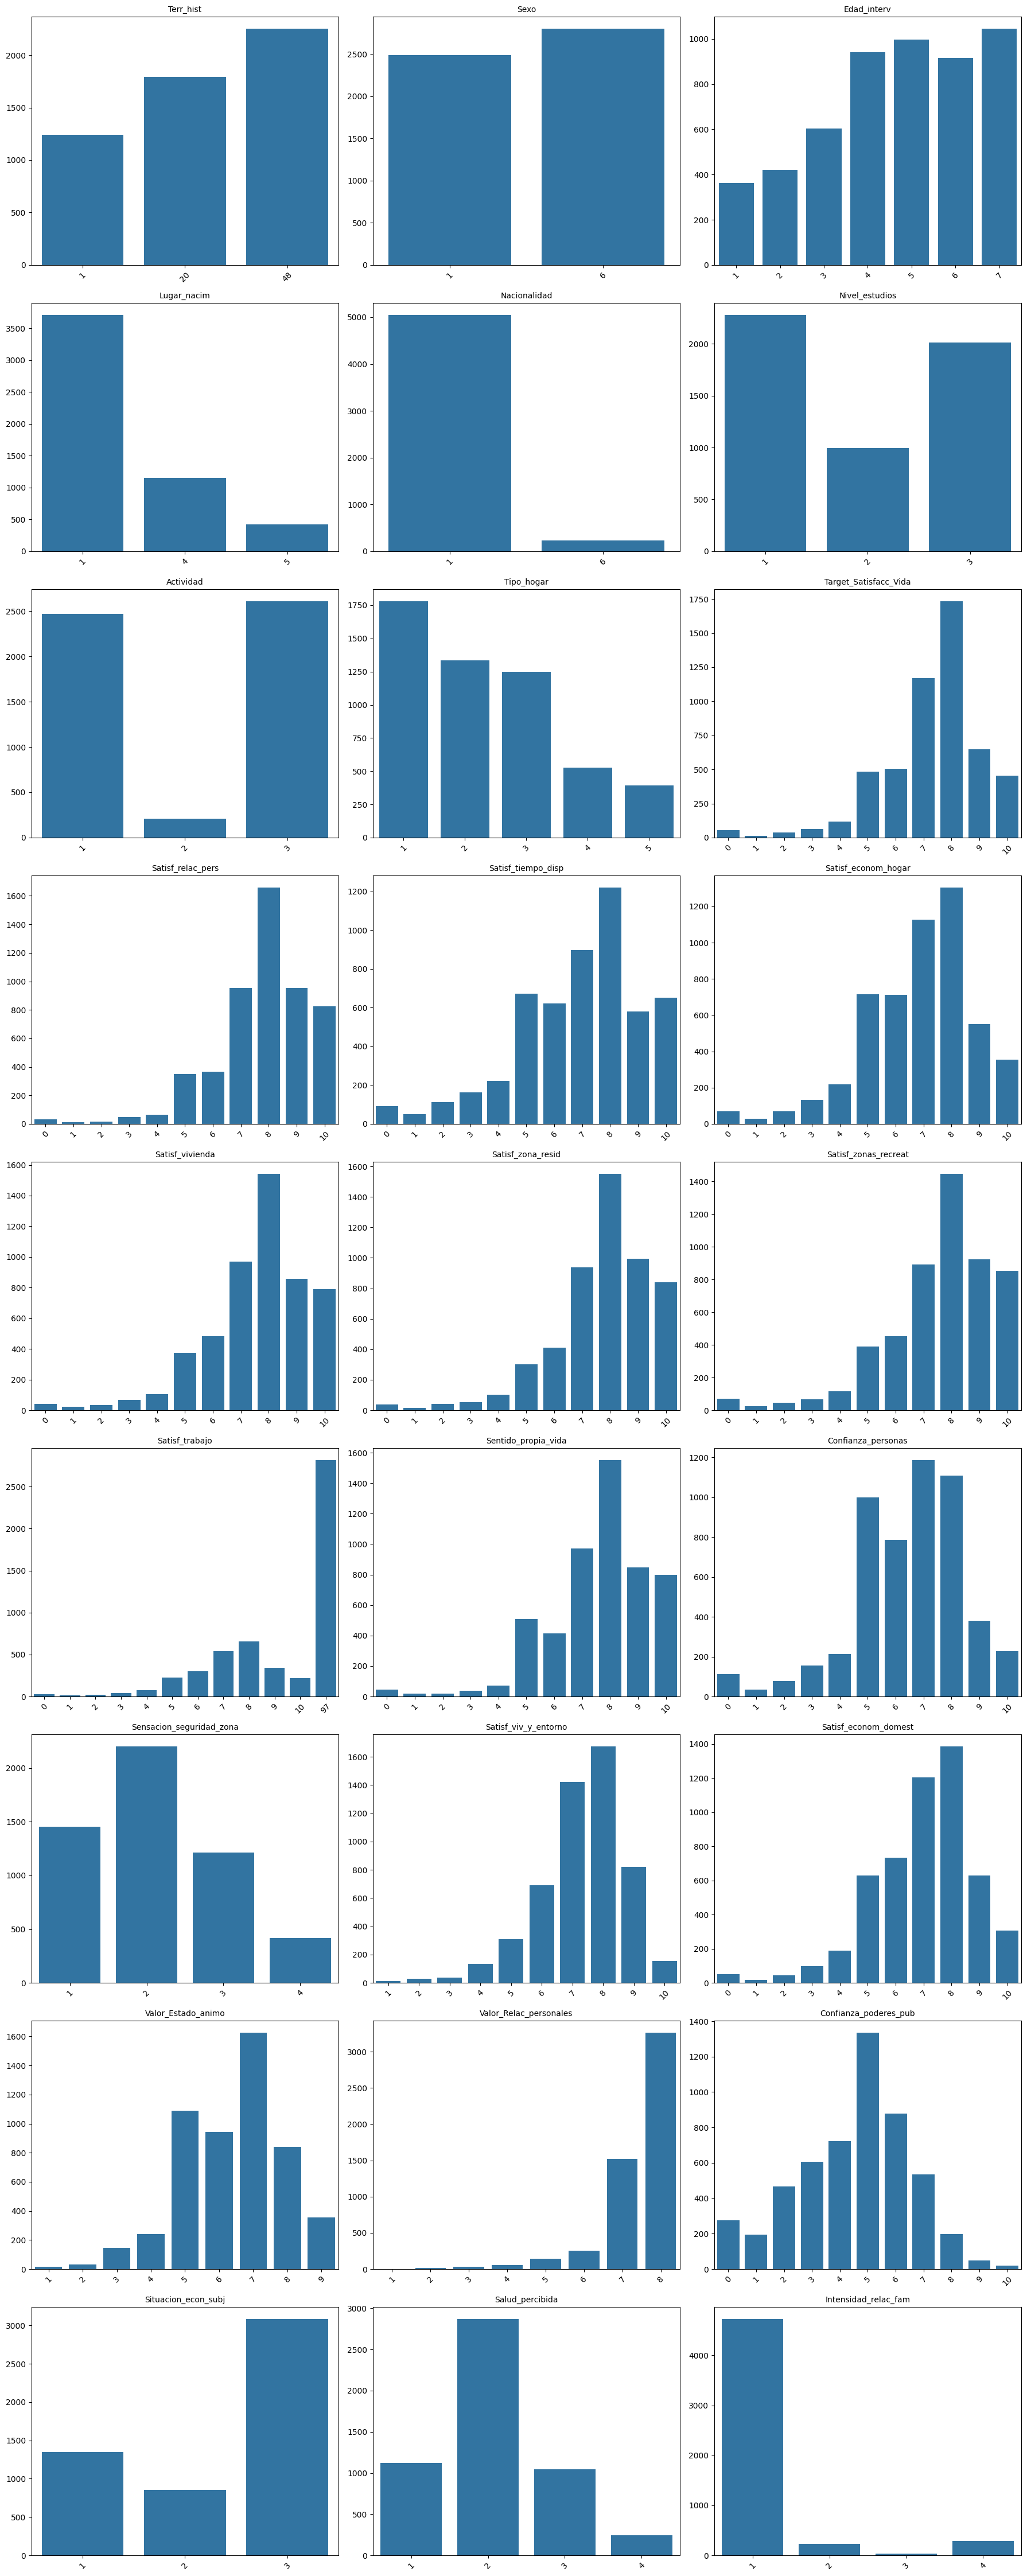

In [29]:
ncols = 3

nvars = len(df_limp.columns)

nrows = math.ceil(nvars / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5*nrows)
)

axes = axes.flatten()

for i, col in enumerate(df_limp.columns):

    # Frecuencias ordenadas
    freq = df_limp[col].value_counts().sort_index()

    sns.barplot(
        x=freq.index,
        y=freq.values,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
# la variable Satisf_trabajo incluye una respuesta, 97, que en realidad es un "no procede"
#por eso lo sustituimos por Nan (luego veré cómo lo manejo al hacer los modelos)

df_limp['Satisf_trabajo'] = df_limp['Satisf_trabajo'].replace(97, np.nan)

In [31]:
# cambiar escalas 1-4
df_limp['Salud_percibida'] = 5 - df_limp['Salud_percibida']
df_limp['Intensidad_relac_fam'] = 5 - df_limp['Intensidad_relac_fam']

# cambiar escala 1-3
df_limp['Sensacion_seguridad_zona'] = 4 - df_limp['Sensacion_seguridad_zona']

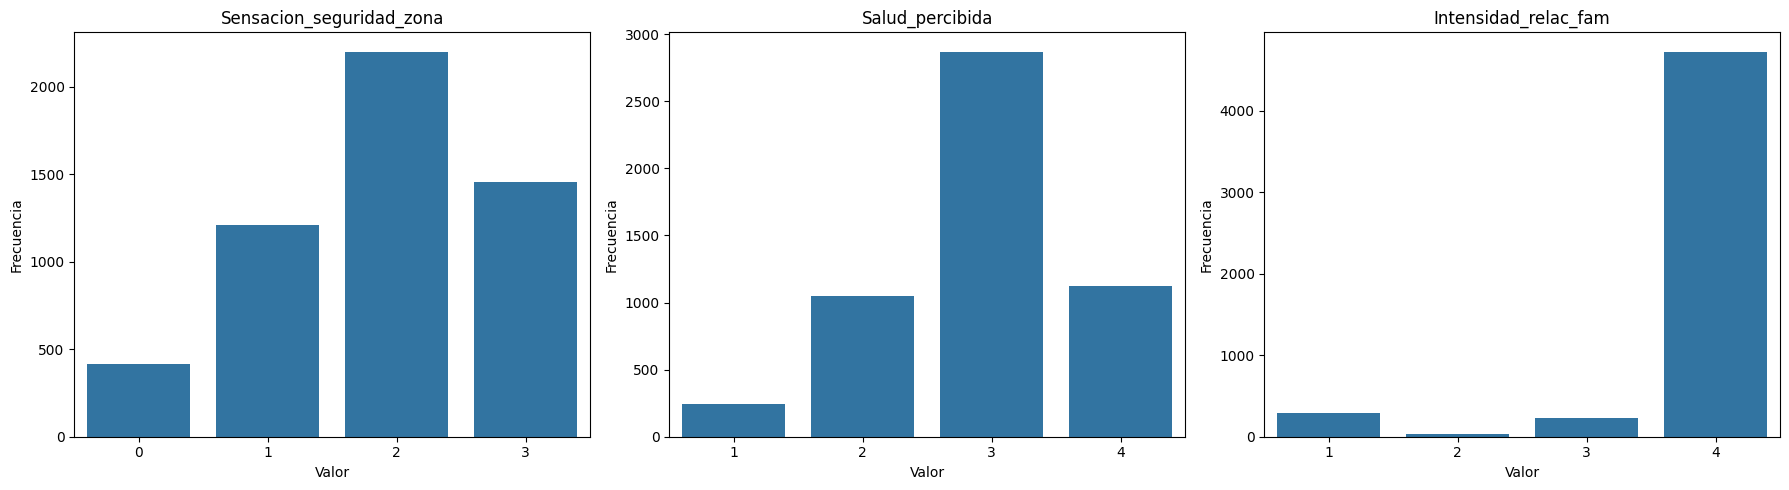

In [32]:
#para ver las gráficas con los valores invertidos: 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = [
    'Sensacion_seguridad_zona',
    'Salud_percibida',
    'Intensidad_relac_fam'
]

for i, col in enumerate(variables):

    freq = df_limp[col].value_counts().sort_index()

    sns.barplot(
        x=freq.index,
        y=freq.values,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

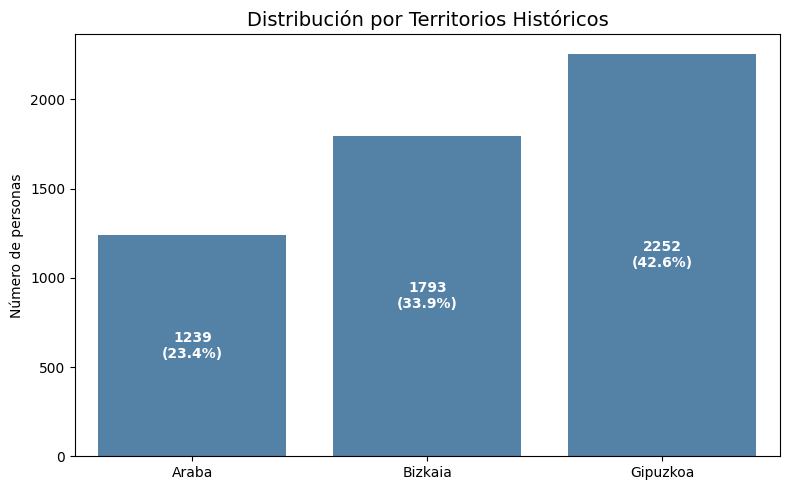

In [33]:

freq = df_limp['Terr_hist'].value_counts().sort_index()

# Etiquetas (para modificar manualmente)
etiquetas = [
    'Araba',
    'Bizkaia',
    'Gipuzkoa'
]

total = freq.sum()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=etiquetas,
    y=freq.values,
    color='steelblue'
)

plt.title('Distribución por Territorios Históricos', fontsize=14)

plt.xlabel('')
plt.ylabel('Número de personas')


for i, valor in enumerate(freq.values):

    porcentaje = valor / total * 100

    ax.text(
        i,
        valor * 0.5,
        f'{valor}\n({porcentaje:.1f}%)',
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

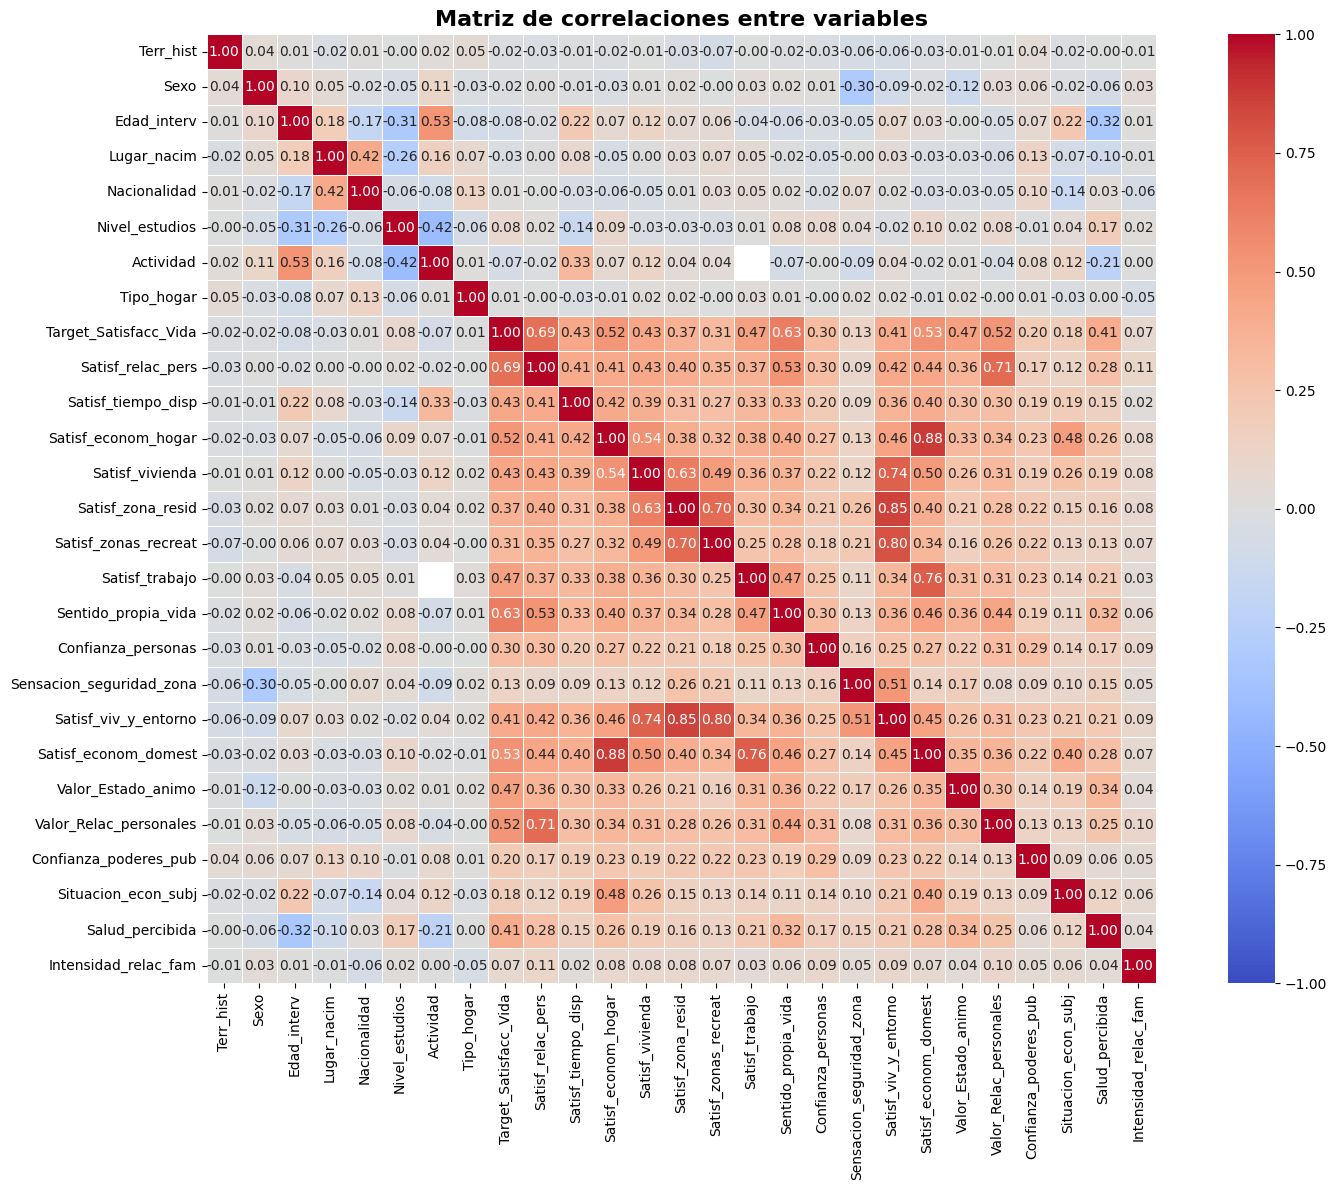

In [34]:
#Hago la matriz de correlaciones para ver relación entre variables

corr = df_limp.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    vmin= -1
)

plt.title(
    'Matriz de correlaciones entre variables',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [35]:
corr_target = (
    df_limp.corr(numeric_only=True)['Target_Satisfacc_Vida']
    .sort_values(ascending=False)
)

corr_target.to_frame(name='Correlacion')

,Correlacion
Target_Satisfacc_Vida,1.000000
Satisf_relac_pers,0.686357
Sentido_propia_vida,0.626431
Satisf_econom_domest,0.532255
Valor_Relac_personales,0.520037
Satisf_econom_hogar,0.515166
Valor_Estado_animo,0.467684
Satisf_trabajo,0.465179
Satisf_vivienda,0.434104
Satisf_tiempo_disp,0.428555


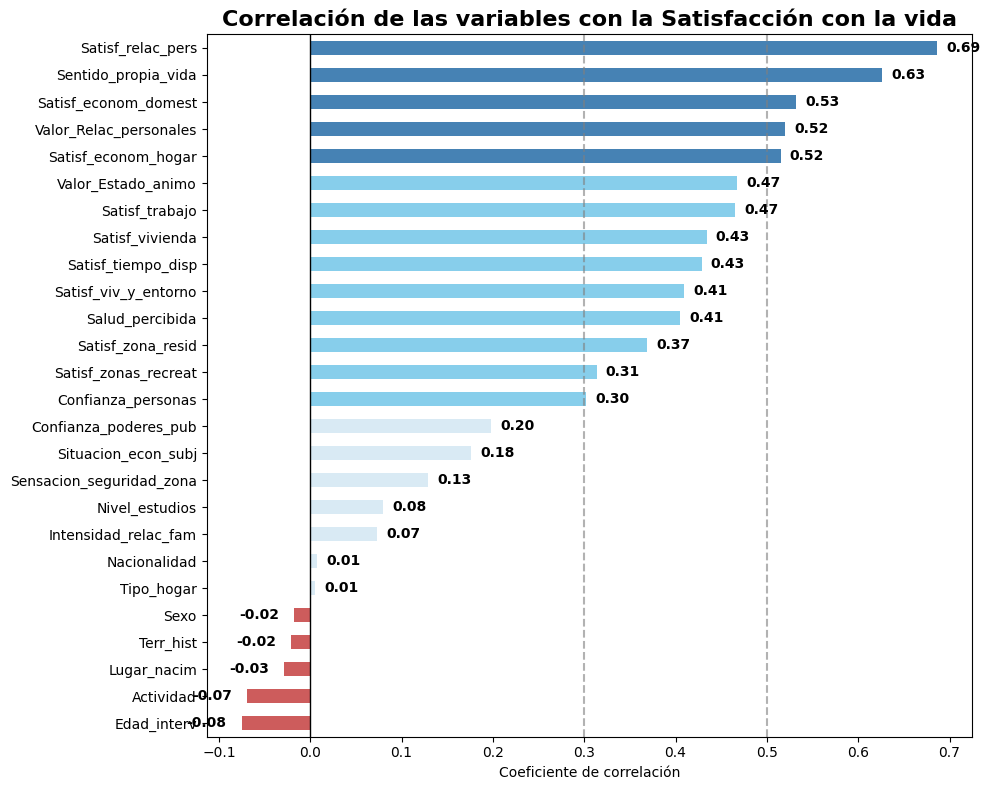

In [ ]:
# Grafica de correlaciones con la target:

corr_target = (
    df_limp.corr(numeric_only=True)['Target_Satisfacc_Vida']
    .drop('Target_Satisfacc_Vida')
    .sort_values()
)

colores = []

for valor in corr_target:

    if valor > 0.50:
        colores.append('steelblue')      # fuerte

    elif valor > 0.30:
        colores.append('skyblue')        # moderada

    elif valor >= 0:
        colores.append('#D9EAF4')           # débil 

    else:
        colores.append('indianred')      # negativa

# Figura
plt.figure(figsize=(10,8))

ax = corr_target.plot(
    kind='barh',
    color=colores
)

plt.title(
    'Correlación de las variables con la Satisfacción con la vida',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente de correlación')
plt.ylabel('')

for i, valor in enumerate(corr_target.values):

    ax.text(
        valor + 0.01 if valor >= 0 else valor - 0.06,
        i,
        f'{valor:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.axvline(0, color='black', linewidth=1)
plt.axvline(0.30, color='grey', linestyle='--', alpha=0.6)
plt.axvline(0.50, color='grey', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

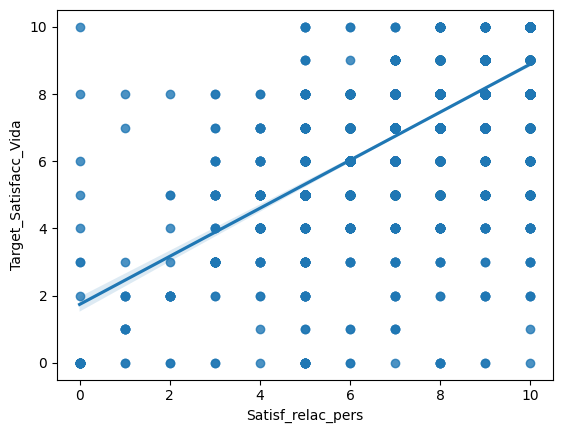

In [37]:
#saco una par de gráficas donde se confirma la relación de regresión lineal entre variables:

sns.regplot(
    data=df_limp,
    x='Satisf_relac_pers',
    y='Target_Satisfacc_Vida'
)

plt.show()

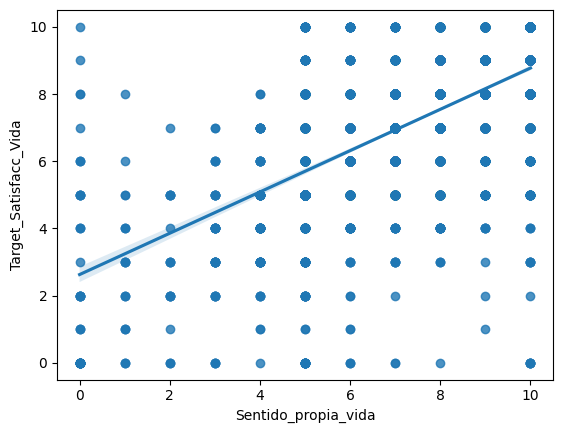

In [38]:

sns.regplot(
    data=df_limp,
    x='Sentido_propia_vida',
    y='Target_Satisfacc_Vida'
)

plt.show()

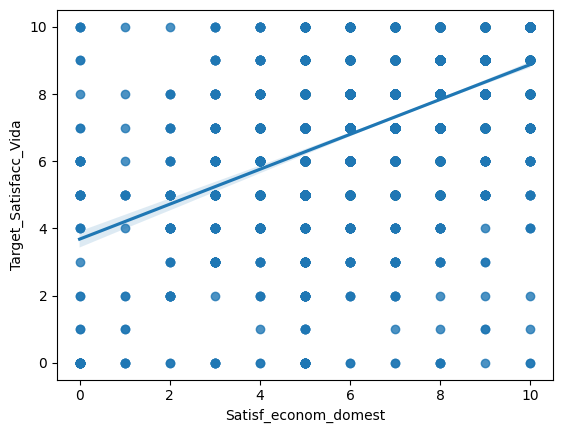

In [39]:
sns.regplot(
    data=df_limp,
    x='Satisf_econom_domest',
    y='Target_Satisfacc_Vida'
)

plt.show()

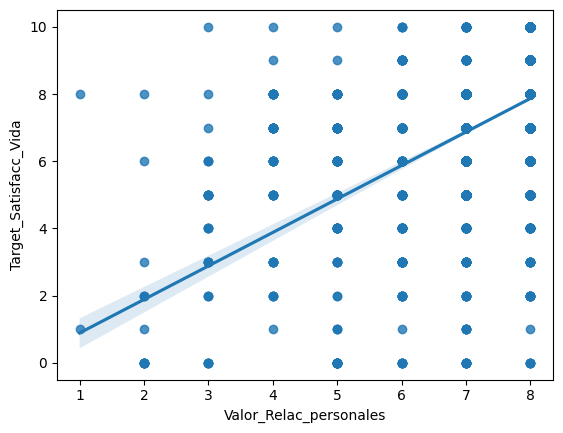

In [40]:
sns.regplot(
    data=df_limp,
    x='Valor_Relac_personales',
    y='Target_Satisfacc_Vida'
)

plt.show()

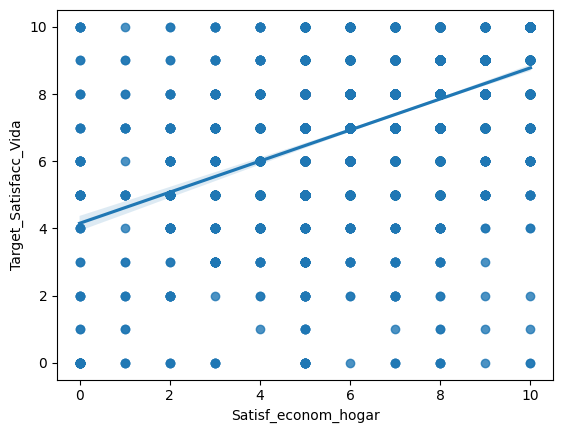

In [41]:
sns.regplot(
    data=df_limp,
    x='Satisf_econom_hogar',
    y='Target_Satisfacc_Vida'
)

plt.show()

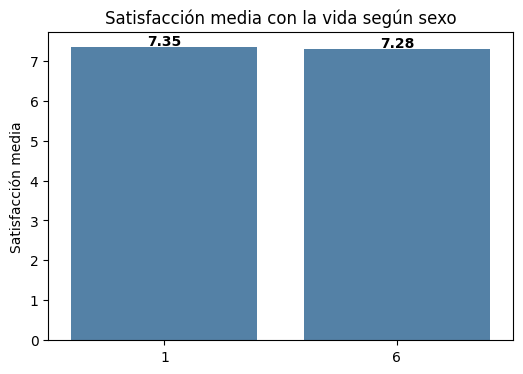

In [42]:
media_target = (
    df_limp.groupby('Sexo')['Target_Satisfacc_Vida']
    .mean()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=media_target.index,
    y=media_target.values,
    color='steelblue'
)

plt.title('Satisfacción media con la vida según sexo')
plt.ylabel('Satisfacción media')
plt.xlabel('')

for i, valor in enumerate(media_target.values):
    ax.text(
        i,
        valor + 0.05,
        f'{valor:.2f}',
        ha='center',
        fontweight='bold'
    )

plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\659712770.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Hombre', 'Mujer'])


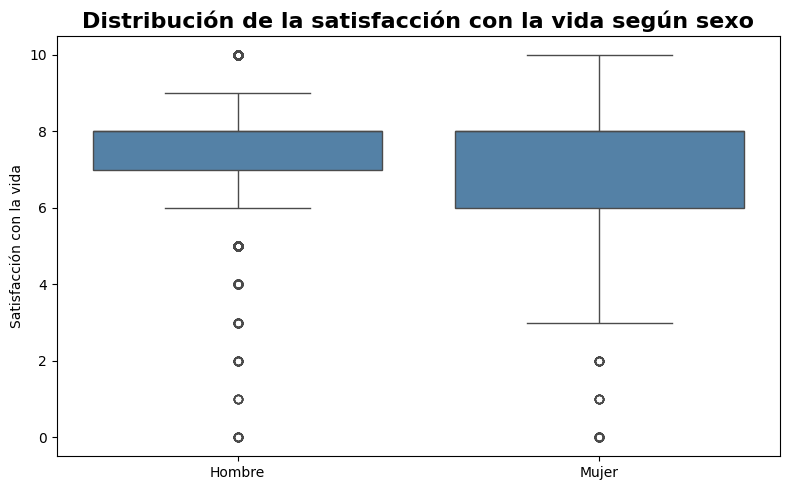

In [43]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Sexo',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Hombre', 'Mujer'])

plt.title(
    'Distribución de la satisfacción con la vida según sexo',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

INTERPRETACIÓN GRÁFICA: 
El diagrama de cajas muestra que la distribución de la satisfacción con la vida es muy similar entre hombres y mujeres.

La mediana se sitúa en torno a valores altos de satisfacción en ambos grupos, aproximadamente entre 7 y 8 puntos sobre 10, lo que indica que la mayoría de las personas encuestadas manifiestan un nivel elevado de satisfacción vital.

No obstante, se observan algunas diferencias:

-Las mujeres presentan una mayor dispersión en las respuestas, con un rango más amplio de valores.
-Entre las mujeres aparecen más respuestas de satisfacción baja (valores cercanos a 0-3).
-Los hombres muestran una distribución más concentrada alrededor de los valores altos de satisfacción.

A pesar de estas diferencias, la superposición entre ambas distribuciones es muy elevada, lo que sugiere que el sexo tiene una influencia limitada sobre la satisfacción con la vida.


C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\3309459359.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Araba', 'Gipuzkoa', 'Bizkaia'])


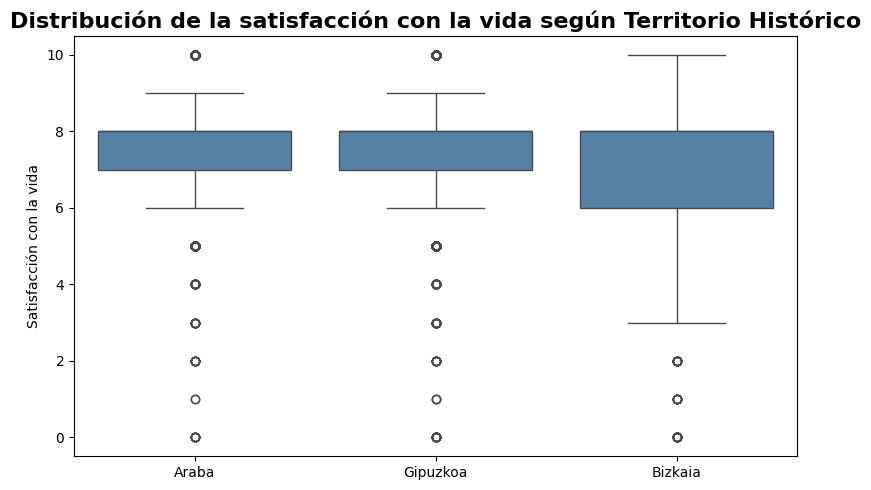

In [49]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Terr_hist',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Araba', 'Gipuzkoa', 'Bizkaia'])

plt.title(
    'Distribución de la satisfacción con la vida según Territorio Histórico',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\1880517282.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['16 a 24', '25 a 34', '35 a 44', '45 a 54', '55 a 64', '65 a 75','>75'])


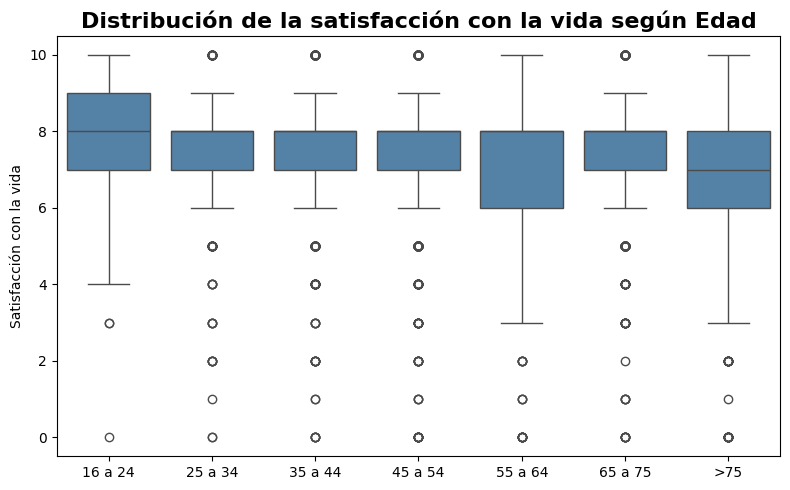

In [47]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Edad_interv',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['16 a 24', '25 a 34', '35 a 44', '45 a 54', '55 a 64', '65 a 75','>75'])

plt.title(
    'Distribución de la satisfacción con la vida según Edad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\4287579864.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ocupados', 'Parados', 'Inactivos'])


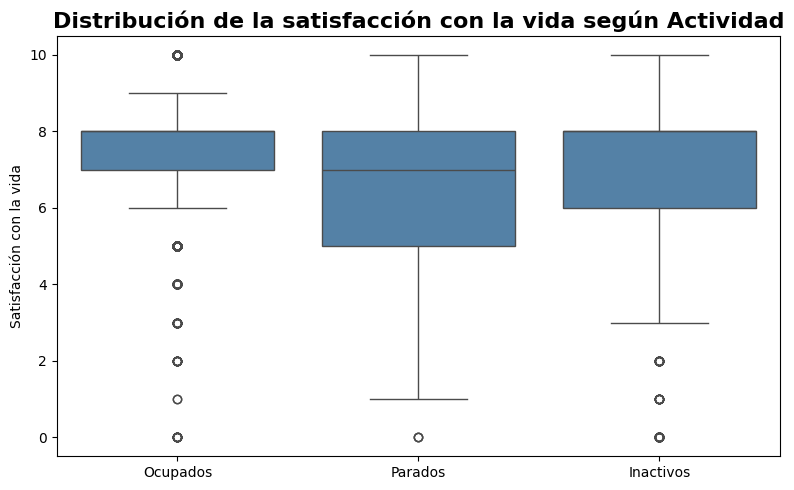

In [48]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Actividad',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Ocupados', 'Parados', 'Inactivos'])

plt.title(
    'Distribución de la satisfacción con la vida según Actividad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\968760874.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Euskadi', 'Resto España', 'Resto mundo'])


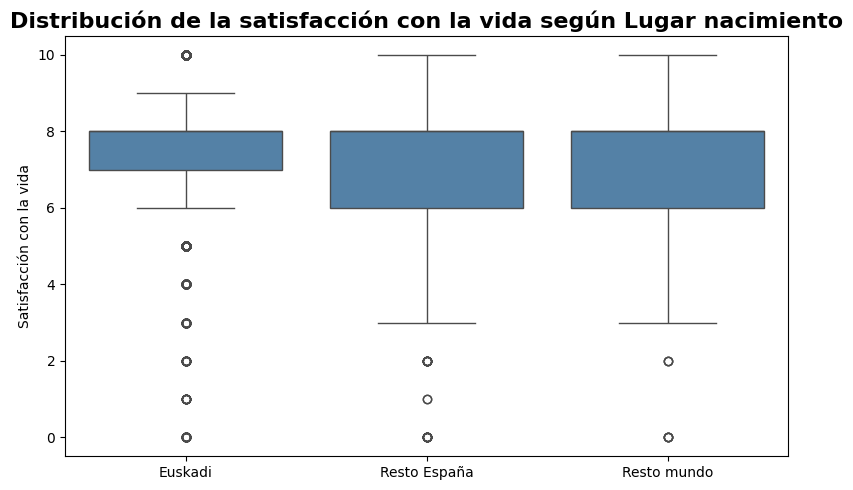

In [50]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Lugar_nacim',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Euskadi', 'Resto España', 'Resto mundo'])

plt.title(
    'Distribución de la satisfacción con la vida según Lugar nacimiento',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\3618228159.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Nacional', 'Extranjero'])


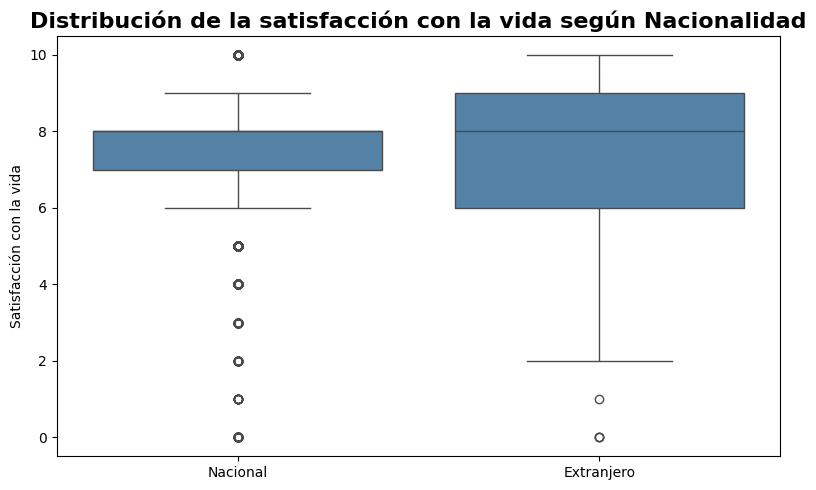

In [51]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Nacionalidad',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Nacional', 'Extranjero'])

plt.title(
    'Distribución de la satisfacción con la vida según Nacionalidad',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\3432925771.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unipersonal', 'Pareja con hijos', 'Pareja sin hijos', 'Padre o madre con hijos', 'Otros'])


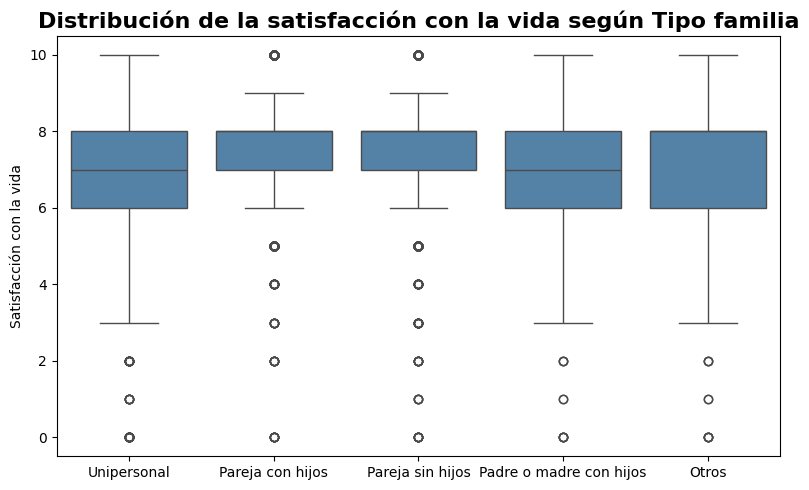

In [52]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Tipo_hogar',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['Unipersonal', 'Pareja con hijos', 'Pareja sin hijos', 'Padre o madre con hijos', 'Otros'])

plt.title(
    'Distribución de la satisfacción con la vida según Tipo familia',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()

C:\Users\Miboo\AppData\Local\Temp\ipykernel_14908\2435644998.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1era etapa de educación secundaria en inferior', ' 2 2ª etapa de educacion secundaria y educación postsecundaria no obligatoria', 'Ed.Superior'])


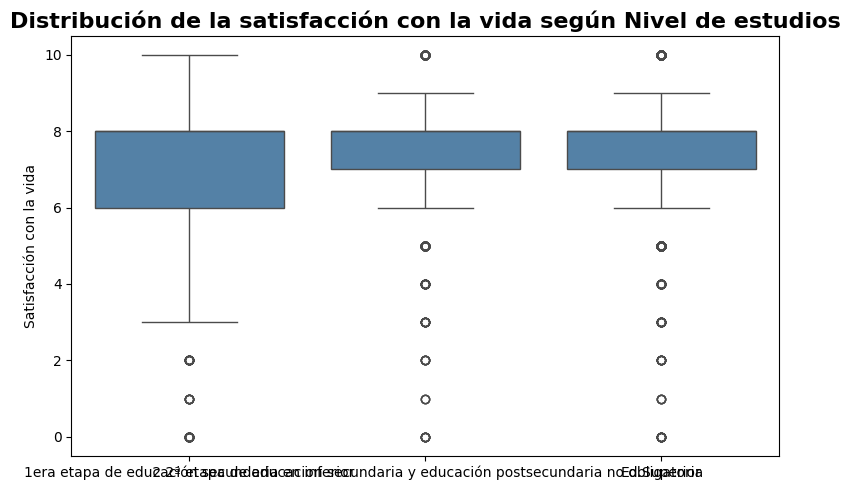

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Nivel_estudios',
    y='Target_Satisfacc_Vida',
    data=df_limp,
    color='steelblue'
)

ax.set_xticklabels(['1era etapa de ed secundaria e inferior', '2ª etapa de ed secundaria y ed postsecundaria no obligatoria', 'Ed.Superior'])

plt.title(
    'Distribución de la satisfacción con la vida según Nivel de estudios',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('')
plt.ylabel('Satisfacción con la vida')

plt.tight_layout()
plt.show()